## Introduction

For my final Statistical Learning Model Selection and Evaluation Project, I will perform exploratory data analysis, model the data using three statistical learning techniques, and identify the best performing model based on evaluation criteria.

The dataset utilized is included in the zip file code submission.

## Dataset Selection

I have selected an animal shelter dataset for this project. It contains numerous fields related to each animal at a variety of shelters in Southern California. Using this data, I plan to create models which aim to classify Outcome Type (such as adoption, euthenasia, or other) based on the animal's characteristics and intake conditions.

Data Source: https://www.animalwelfaredatacenter.org/#:~:text=Visit%20our%20public%20animal%20shelter%20dashboard%20to%20review,insights%2C%20and%20access%20to%20public%20animal%20shelter%20data.



### Exploratory Analysis

The following imports allow for dataframe manipulation and file reading from Google Drive.

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/gdrive')
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# Evaluation
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sn

from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score
import seaborn as sns
import numpy as np

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


Using the head() function, we can view the fields present in the data, along with some of their numerical and categorical values. According to the output of the shape() function, there are 32 columns and 29,885 rows.

In [ ]:
#Read and preview dataframe
df = pd.read_csv('gdrive/My Drive/AWDC_Shelter_Dashboard_Data.csv')
df.head()

,Animal Type,Primary Breed,Intake Type,Outcome Type,Shelter Full Name,Shelter System,Animal Id,Animal Name,Sex,Primary Color,...,Outcome Request,Outcome Subtype,Temperament,Animal Size,Weight,Crossing,Jurisdiction,Length Of Stay,Same Day Outcome,Altered Flag
0,DOG,BOXER,RETURN,ADOPTION,WESTERN RIVERSIDE,RIVERSIDE COUNTY,A1771320,TIGGER,S,BR BRINDLE / WHITE,...,NaN,NEW,NaN,LARGE,49.00,NaN,JURUPA VALLEY,0,1,1
1,DOG,SHEPHERD / MIX,OWNER SUR,ADOPTION,COACHELLA VALLEY,RIVERSIDE COUNTY,A1784937,NaN,S,BROWN,...,NaN,NEW,NaN,PUPPY,13.87,NaN,COACHELLA CITY,4,0,1
2,DOG,LABRADOR RETR / MIX,CONFISCATE,RTO,WESTERN RIVERSIDE,RIVERSIDE COUNTY,A1784948,NAUGHTY,S,BLACK / WHITE,...,NaN,COUNTER,NaN,LARGE,77.50,NaN,RIVERSIDE,10,0,1
3,DOG,CHIHUAHUA SH,STRAY,RTO,COACHELLA VALLEY,RIVERSIDE COUNTY,A1785531,NaN,M,TAN,...,NaN,COUNTER,NaN,SMALL,7.00,NaN,INDIO CITY,1,0,0
4,DOG,YORKSHIRE TERR,STRAY,RTO,WESTERN RIVERSIDE,RIVERSIDE COUNTY,A1785533,RUBY,S,TAN / GRAY,...,NaN,COUNTER,NaN,SMALL,9.70,NaN,FONTANA,3,0,1


In [ ]:
df.shape

(29855, 32)

The column names are shortened, are listed below, and their amount of null values are also displayed. Some columns (such as Secondary Color, Breed Group, and Animal Status) have no data in them for any row or very little data, so these columns can be dropped from the dataframe.

In [ ]:
df.isna().sum()

,0
Animal Type,0
Primary Breed,0
Intake Type,0
Outcome Type,627
Shelter Full Name,0
Shelter System,0
Animal Id,0
Animal Name,18129
Sex,0
Primary Color,0


In [ ]:
df = df.drop(['Secondary Color','Breed Group','Animal Status','Temperament','Crossing','Kennel Substatus','Intake Reason','Outcome Request','Outcome Subtype','Animal Name'], axis = 1)

To simplify the dataset further, I elected to consider only Dogs from Western Riverside Shelter in my models.

In [ ]:
WR_df = df[df['Shelter Full Name']=="WESTERN RIVERSIDE"]

In [ ]:
WR_DOGS_df = WR_df[WR_df['Animal Type']=="DOG"]

Further inspection of the data revealed that some dogs are dead upon intake, so I elected to remove these rows since their Output Type is always Disposal and they may be missing Age and Weight characteristics. The resulting shape of the new dataframe is 22 columns and 8853 rows.

In [ ]:
WR_DOGS_df = WR_DOGS_df[WR_DOGS_df["Intake Condition"] != "DEAD"]

In [ ]:
WR_DOGS_df.shape

(8218, 22)

### Preprocessing

At this point, Outcome Type, Age at Intake, Weight, and Animal Size are still null. Since I anticipate using Outcome Type as a target, and Age, Weight, or Animal Size as independent variables, I will consider methods of imputing data to these fields.

In [ ]:
WR_DOGS_df.isna().sum()

,0
Animal Type,0
Primary Breed,0
Intake Type,0
Outcome Type,237
Shelter Full Name,0
Shelter System,0
Animal Id,0
Sex,0
Primary Color,0
Kennel Status,0



First, I will consider Outcome Type possibilities. In this case, I do not want to assume nulls fit into any existing outcome type, so I will replace those nulls with 'OTHER' as a description.

In [ ]:
WR_DOGS_df['Outcome Type'].fillna("OTHER", inplace=True)

<ipython-input-224-210f993e0e9d>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  WR_DOGS_df['Outcome Type'].fillna("OTHER", inplace=True)


Next I will address Age at Intake. With Age at Intake being null for only 2% of animals and no real way to guess Age based on the other points, I will convert null Ages to the average of all other ages, which lands at about 1047 days.

In [ ]:
WR_DOGS_df['Age At Intake Days'].fillna(WR_DOGS_df['Age At Intake Days'].mean(),inplace=True)

<ipython-input-225-c38e1d777de4>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  WR_DOGS_df['Age At Intake Days'].fillna(WR_DOGS_df['Age At Intake Days'].mean(),inplace=True)


Finally, I will impute some weights into the Weight column. This will be based on an average grouped by Animal Size, to hopefully get better estimates of weight for animals that are missing this characteristic.

In [ ]:
WR_DOGS_df.groupby('Animal Size')['Weight'].mean()

,Weight
Animal Size,
KITTN,8.050000
LARGE,62.949166
MED,45.479908
PUPPY,18.578166
SMALL,15.119864
TOY,9.047541
UNKWN,44.549324
X-LRG,97.903922


In [ ]:
WR_DOGS_df.loc[(WR_DOGS_df['Animal Size']=='KITTN') & WR_DOGS_df['Weight'].isnull(), 'Weight'] = 8.05
WR_DOGS_df.loc[(WR_DOGS_df['Animal Size']=='LARGE') & WR_DOGS_df['Weight'].isnull(), 'Weight'] = 62.94
WR_DOGS_df.loc[(WR_DOGS_df['Animal Size']=='MED') & WR_DOGS_df['Weight'].isnull(), 'Weight'] = 45.47
WR_DOGS_df.loc[(WR_DOGS_df['Animal Size']=='PUPPY') & WR_DOGS_df['Weight'].isnull(), 'Weight'] = 18.57
WR_DOGS_df.loc[(WR_DOGS_df['Animal Size']=='SMALL') & WR_DOGS_df['Weight'].isnull(), 'Weight'] = 15.11
WR_DOGS_df.loc[(WR_DOGS_df['Animal Size']=='TOY') & WR_DOGS_df['Weight'].isnull(), 'Weight'] = 9.04
WR_DOGS_df.loc[(WR_DOGS_df['Animal Size']=='UNKWN') & WR_DOGS_df['Weight'].isnull(), 'Weight'] = 44.54
WR_DOGS_df.loc[(WR_DOGS_df['Animal Size']=='X-LRG') & WR_DOGS_df['Weight'].isnull(), 'Weight'] = 97.90

Going back to Animal Size, there is one more row without a size or Weight. Since this dog is a Shih Tzu/Mix, I will assume it is TOY sized with 9.04 weight.

In [ ]:
WR_DOGS_df.loc[(WR_DOGS_df['Weight'].isnull()) | WR_DOGS_df['Animal Size'].isnull()]

,Animal Type,Primary Breed,Intake Type,Outcome Type,Shelter Full Name,Shelter System,Animal Id,Sex,Primary Color,Kennel Status,...,Intake Condition,Intake Subtype,Hold Notify,Outcome Date,Animal Size,Weight,Jurisdiction,Length Of Stay,Same Day Outcome,Altered Flag
2785,DOG,SHIH TZU / MIX,EUTH REQ,EUTH,WESTERN RIVERSIDE,RIVERSIDE COUNTY,A0725783,S,CREAM / WHITE,UNAVAIL,...,AGED,OTC,NO HOLD,24-JUL-24,NaN,NaN,RIVERSIDE,0,1,1


In [ ]:
WR_DOGS_df.loc[(WR_DOGS_df['Weight'].isnull()) | WR_DOGS_df['Animal Size'].isnull(), 'Animal Size'] = "TOY"
WR_DOGS_df.loc[(WR_DOGS_df['Weight'].isnull()) | WR_DOGS_df['Animal Size'].isnull(), 'Weight'] = 9.04

There are now no remaining nulls in the data.

In [ ]:
WR_DOGS_df.isna().sum()

,0
Animal Type,0
Primary Breed,0
Intake Type,0
Outcome Type,0
Shelter Full Name,0
Shelter System,0
Animal Id,0
Sex,0
Primary Color,0
Kennel Status,0


Now, I will check the distributions of some of the columns to explore the Modeling possibilities.

As specified before, all Animal Types are dogs for this subset of the original data.

In [ ]:
WR_DOGS_df['Animal Type'].value_counts()

,count
Animal Type,
DOG,8218


There are over 400 distinct breeds, most appearing as mixes of multiple breeds. With so many options, this characteristic may not be an ideal categorical variable for predicting Outcome Type.

In [ ]:
#WR_DOGS_df['Primary Breed'].unique() ## This lists all 442 breed combinations
WR_DOGS_df['Primary Breed'].value_counts()

,count
Primary Breed,
GERM SHEPHERD,894
PIT BULL,596
SHEPHERD / MIX,400
CHIHUAHUA SH,381
SIBERIAN HUSKY,372
...,...
GERM SHEPHERD / CHINESE SHARPEI,1
HARRIER,1
AUST CATTLE DOG / GREAT DANE,1


Primary color also has almost 200 distinct values due to being a combination of colors for some dogs. When extracting just the first color, the number is reduced to 30, which may be more manageable as a categorical predictor.

In [ ]:
WR_DOGS_df['Primary Color'].value_counts()
WR_DOGS_df[['First Color','Second Color']] = WR_DOGS_df['Primary Color'].str.split(" / ",expand=True)
WR_DOGS_df = WR_DOGS_df.drop(['Second Color'], axis=1)

Along with the new First Color column, the remaining categorical variables, Intake Type, Sex, Intake Condition, Intake Subtype, and Animal Size all have potential for being used as categorical predictors of Outcome Type. It is clear that there are dominant characteristics in each column which is not an ideal distribution, but this breakdown will be reflected in the training and test sets to ensure cleaner analysis.

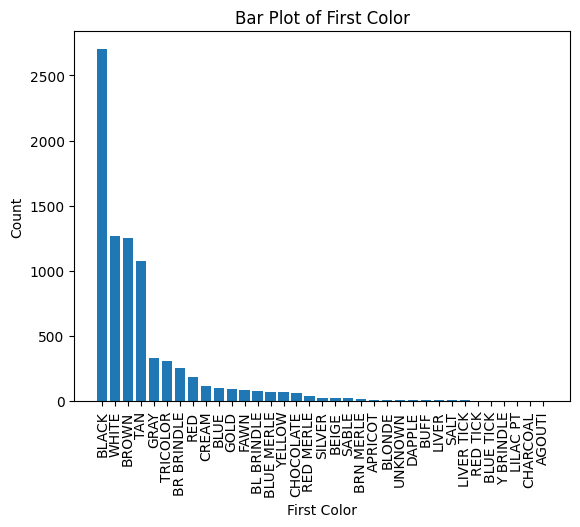

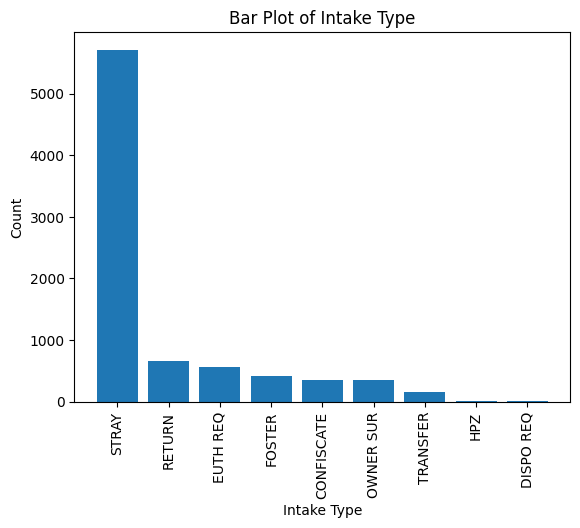

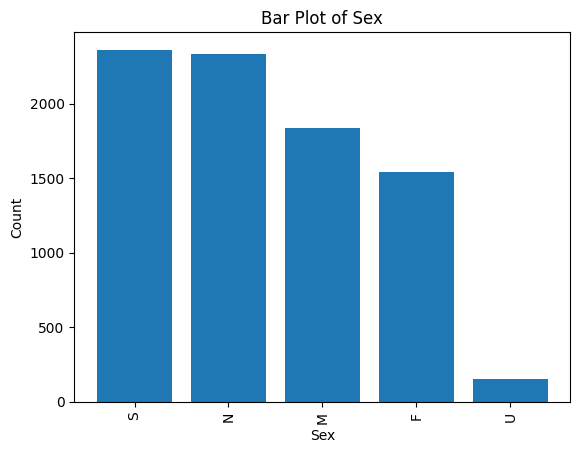

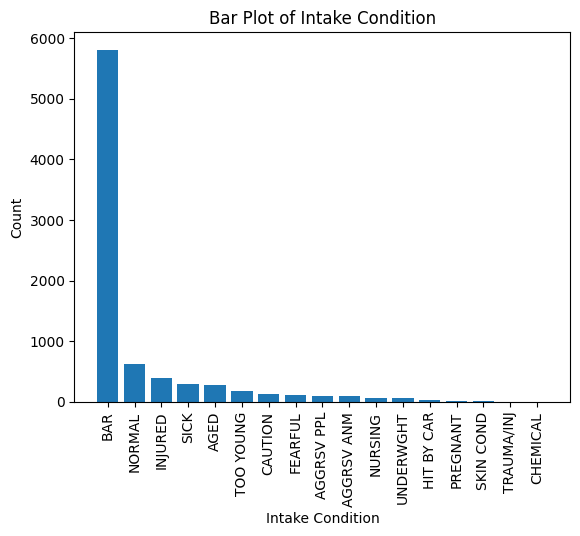

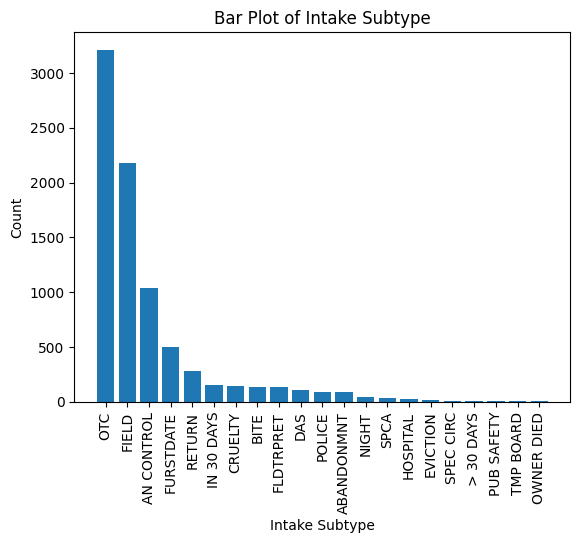

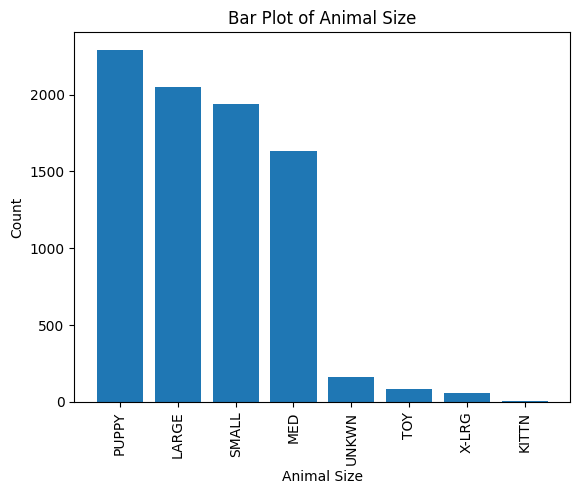

In [ ]:
counts = WR_DOGS_df['First Color'].value_counts()
plt.bar(counts.index, counts.values)
plt.title('Bar Plot of First Color')
plt.xlabel('First Color')
plt.ylabel('Count')
plt.xticks(rotation='vertical')
plt.show()

counts = WR_DOGS_df['Intake Type'].value_counts()
plt.bar(counts.index, counts.values)
plt.title('Bar Plot of Intake Type')
plt.xlabel('Intake Type')
plt.ylabel('Count')
plt.xticks(rotation='vertical')
plt.show()

counts = WR_DOGS_df['Sex'].value_counts()
plt.bar(counts.index, counts.values)
plt.title('Bar Plot of Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.xticks(rotation='vertical')
plt.show()

counts = WR_DOGS_df['Intake Condition'].value_counts()
plt.bar(counts.index, counts.values)
plt.title('Bar Plot of Intake Condition')
plt.xlabel('Intake Condition')
plt.ylabel('Count')
plt.xticks(rotation='vertical')
plt.show()

counts = WR_DOGS_df['Intake Subtype'].value_counts()
plt.bar(counts.index, counts.values)
plt.title('Bar Plot of Intake Subtype')
plt.xlabel('Intake Subtype')
plt.ylabel('Count')
plt.xticks(rotation='vertical')
plt.show()

counts = WR_DOGS_df['Animal Size'].value_counts()
plt.bar(counts.index, counts.values)
plt.title('Bar Plot of Animal Size')
plt.xlabel('Animal Size')
plt.ylabel('Count')
plt.xticks(rotation='vertical')
plt.show()

For numerical variables, Age at Intake Days, Weight, and Length of Stay are all potential candidates for predictors. However, their distributions are all positively skewed and may not provide as great of insights compared to data with no skew.

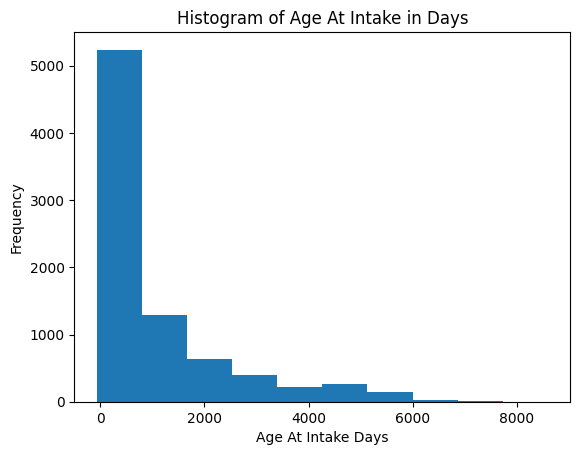

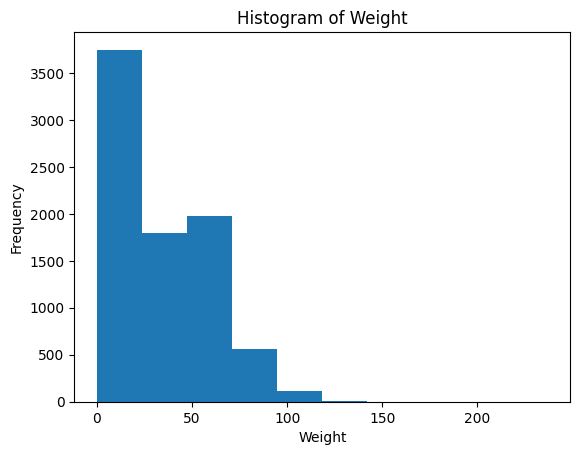

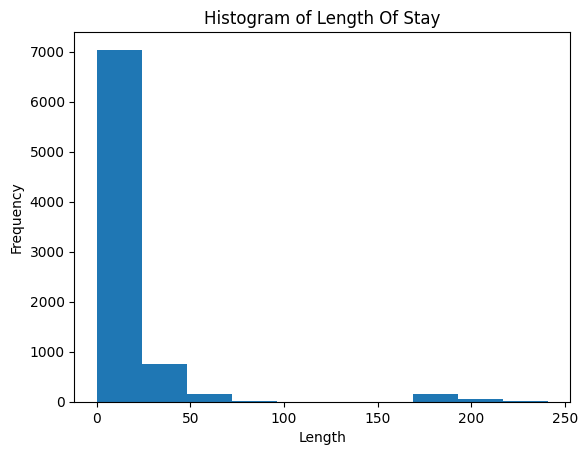

In [ ]:
plt.hist(WR_DOGS_df['Age At Intake Days'], bins = 10)
plt.title('Histogram of Age At Intake in Days')
plt.xlabel('Age At Intake Days')
plt.ylabel('Frequency')
plt.show()

plt.hist(WR_DOGS_df['Weight'], bins = 10)
plt.title('Histogram of Weight')
plt.xlabel('Weight')
plt.ylabel('Frequency')
plt.show()

plt.hist(WR_DOGS_df['Length Of Stay'], bins = 10)
plt.title('Histogram of Length Of Stay')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.show()

My desired target variable of Outcome Type seems reasonable for classification based models, and could easily be separated between Adoption or not for binary analysis.

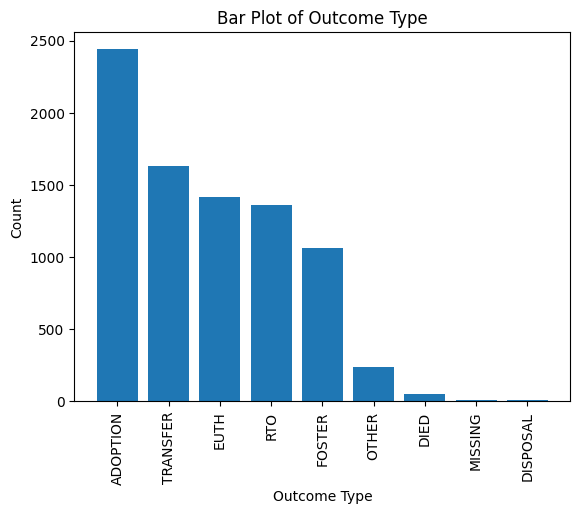

In [ ]:
counts = WR_DOGS_df['Outcome Type'].value_counts()
plt.bar(counts.index, counts.values)
plt.title('Bar Plot of Outcome Type')
plt.xlabel('Outcome Type')
plt.ylabel('Count')
plt.xticks(rotation='vertical')
plt.show()

As a final preprocessing step, One-Hot Encoding is applied to the categorical variables and the target variable for use in the models. Then, the numerical variables are added to the X data and the ADOPTION outcome is extracted from the target table.

In [ ]:
ohe = OneHotEncoder(handle_unknown='ignore',sparse_output=False).set_output(transform='pandas')
ohetransform_preds = ohe.fit_transform(WR_DOGS_df[['First Color','Intake Type','Sex','Intake Condition','Intake Subtype', 'Animal Size']])
ohetransform_target = ohe.fit_transform(WR_DOGS_df[['Outcome Type']])

X = ohetransform_preds
X[['Age At Intake Days','Weight','Length Of Stay']] = (WR_DOGS_df[['Age At Intake Days','Weight','Length Of Stay']])
Y_matrix = ohetransform_target

Y = Y_matrix['Outcome Type_ADOPTION']

Finally, the data is split into training and test sets for use in the three models using the train_test_split method to ensure each subset has similar distributions for the features and targets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size = 0.2, random_state = 101)

## Models




### Model 1: Binary Logistic Regression

#### Rationale

For my first modeling attempt, I will do a logistic regression model. Since I have extracted the ADOPTION Outcome Type specifically, the data is aiming to predict a binary outcome (Adoption or Not Adoption). Binary Logisitic Regression is suitable for this goal as it utilizes the features to predict model the probability of observing the desired outcome.

To fit this model, I have utilized the LogisticRegression function from the sklearn.linear_model library.

In [ ]:
from sklearn.linear_model import LogisticRegression

model_log = LogisticRegression()
model_log.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

#### Evaluation

Due to the use of numerous features, it is difficult to visualize the logistic regression model, but we can check that its output probabilities by using the predict_proba() function on the X_test set and comparing to the predictions on the X_test set and actual values in the y_test set.

In [ ]:
y_prob = model_log.predict_proba(X_test)[:,1]
y_pred = model_log.predict(X_test)

y_test = list(y_test)
for i in np.arange(10):
  print(f'TEST',i+1)
  print(f'Predicted Probability:',y_prob[i])
  print(f'Predicted Outcome:',y_pred[i])
  print(f'Actual Outcome:', y_test[i])
  print()

TEST 1
Predicted Probability: 0.698931713674643
Predicted Outcome: 1.0
Actual Outcome: 1.0

TEST 2
Predicted Probability: 0.2542041428108686
Predicted Outcome: 0.0
Actual Outcome: 0.0

TEST 3
Predicted Probability: 0.5111114980427947
Predicted Outcome: 1.0
Actual Outcome: 0.0

TEST 4
Predicted Probability: 0.7631734558351161
Predicted Outcome: 1.0
Actual Outcome: 0.0

TEST 5
Predicted Probability: 0.47216354614879813
Predicted Outcome: 0.0
Actual Outcome: 1.0

TEST 6
Predicted Probability: 0.9527181547858868
Predicted Outcome: 1.0
Actual Outcome: 1.0

TEST 7
Predicted Probability: 0.03436723197603675
Predicted Outcome: 0.0
Actual Outcome: 0.0

TEST 8
Predicted Probability: 0.01787542804633736
Predicted Outcome: 0.0
Actual Outcome: 0.0

TEST 9
Predicted Probability: 0.01236695048615634
Predicted Outcome: 0.0
Actual Outcome: 0.0

TEST 10
Predicted Probability: 0.007554991905321676
Predicted Outcome: 0.0
Actual Outcome: 0.0



From the 10 predictions displayed above, the probability of Adoption is accurately leaning to the actual outcome for Tests 1, 2, 6, 7, 8, 9, and 10, but is inaccurate for Tests 3, 4, and 5. For Tests 3 and 5 the prediction was very nearly correct and only slightly skewed towards the incorrect output. The added output of a probability value helps define how much confidence can be placed in any model outcome, which is a great benefit of using Logisitic Regression for this dataset.

This small indicates an accuracy of about 70%, but I will use the accuracy_score function from sklearn.metrics to get a better idea of the accuracy.

The sklearn.metrics library is used below to compute some evaluation metrics on Model 1.

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, mean_squared_error
y_pred = model_log.predict(X_test)

print("Confusion Matrix: ",
          confusion_matrix(y_test, y_pred))
print("Accuracy Score: ",
          accuracy_score(y_test, y_pred))
print("Classification Report: ",
          classification_report(y_test, y_pred))

Confusion Matrix:  [[1004  148]
 [ 141  351]]
Accuracy Score:  0.8242092457420924
Classification Report:                precision    recall  f1-score   support

         0.0       0.88      0.87      0.87      1152
         1.0       0.70      0.71      0.71       492

    accuracy                           0.82      1644
   macro avg       0.79      0.79      0.79      1644
weighted avg       0.82      0.82      0.82      1644



The confusion matrix indicates that a majority of predicted values match actual values (1004) based on the test set, and therefore are true positive values. The counts of false positive and false negative are pretty similar at 148 and 141. The true negatve count is pretty low at 351, but this makes sense when we recall that there is an uneven distribution of Outcome Type with more non-adoption outcomes than adoption outcomes.

The accuracy score of this model is 82.42%, higher than the small sample discussed previously.

The classification report gives values of precision, recall, f1-score, and support, all of which are calculated from the confusion matrix. For the non-adoption and adoption outcomes, precision and recall are nearly identical. This indicates that the model is equally good at identifying adoption outcomes and retrieving adoption outcomes. The f1-scores both approach the range of 0.7-0.9 indicating good performance of the model, though there is a slight bias in favor of predicting non-adoption outcomes due to the data distribution.

### Model 2: Decision Tree

#### Rationale

For my second modeling attempt, I will do a Decision Tree model. Again, the data is aiming to predict a binary outcome (Adoption or Not Adoption). Decision trees are a good approach for modeling this classifier because they offer feature importance, identifying the most influential features. Like binary logistic regression, decision trees also return a prediction probability value that gives more support to the prediction outputs of the model.

To fit this model, I have utilized the DecisionTreeClassifier function from the sklearn.tree library as well as the plot_tree function to visualize the model.

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

[Text(0.5875, 0.9166666666666666, 'Intake Type_RETURN <= 0.5\ngini = 0.417\nsamples = 6574\nvalue = [4628, 1946]'),
 Text(0.32, 0.75, 'Sex_S <= 0.5\ngini = 0.374\nsamples = 6050\nvalue = [4543, 1507]'),
 Text(0.45375, 0.8333333333333333, 'True  '),
 Text(0.16, 0.5833333333333334, 'Sex_N <= 0.5\ngini = 0.282\nsamples = 4389\nvalue = [3645, 744]'),
 Text(0.08, 0.4166666666666667, 'Intake Type_FOSTER <= 0.5\ngini = 0.04\nsamples = 2764\nvalue = [2708, 56]'),
 Text(0.04, 0.25, 'Length Of Stay <= 3.5\ngini = 0.033\nsamples = 2680\nvalue = [2635, 45]'),
 Text(0.02, 0.08333333333333333, 'gini = 0.003\nsamples = 783\nvalue = [782, 1]'),
 Text(0.06, 0.08333333333333333, 'gini = 0.045\nsamples = 1897\nvalue = [1853, 44]'),
 Text(0.12, 0.25, 'Animal Size_SMALL <= 0.5\ngini = 0.228\nsamples = 84\nvalue = [73, 11]'),
 Text(0.1, 0.08333333333333333, 'gini = 0.167\nsamples = 76\nvalue = [69, 7]'),
 Text(0.14, 0.08333333333333333, 'gini = 0.5\nsamples = 8\nvalue = [4, 4]'),
 Text(0.24, 0.4166666666666

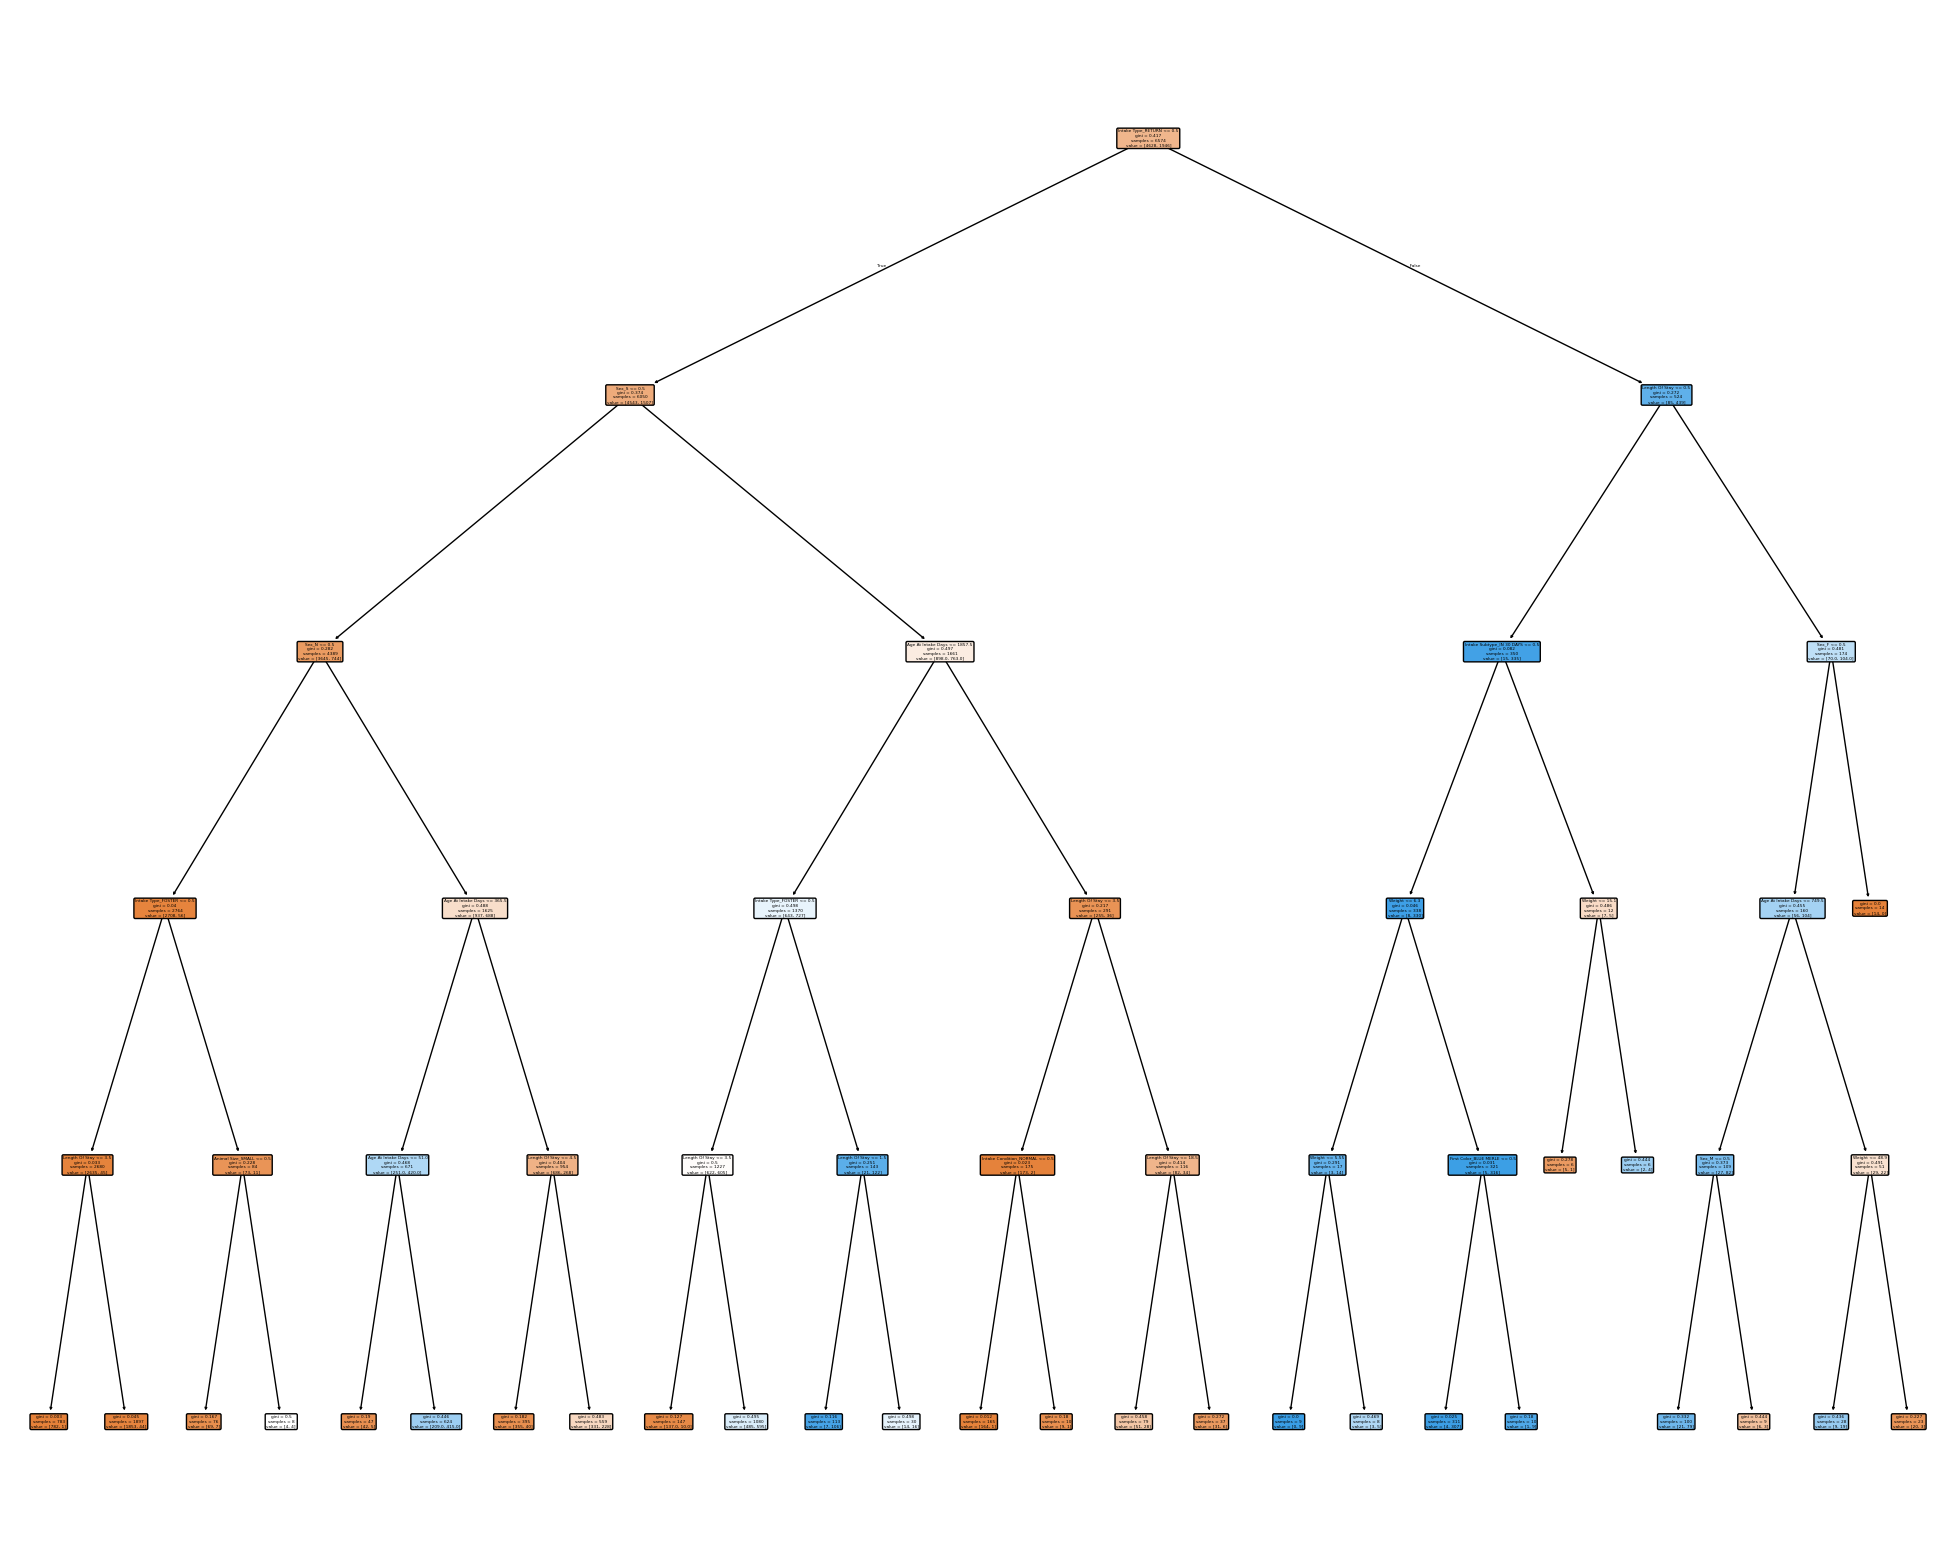

In [ ]:
dtree = DecisionTreeClassifier(criterion="gini",
                               random_state=100,
                               max_depth=5,
                               min_samples_leaf=5)
dtree = dtree.fit(X_train, y_train)
features = list(X)
fig = plt.figure(figsize=(25,20))
plot_tree(dtree, feature_names=features, filled=True, rounded=True)

#### Evaluation

In creating the Decision Tree model, I selected the gini index criterion and increased max depth until I saw no further improvements in accuracy, and landed on a max depth of 5. While the output is difficult to read due to the tree's large size, the text output identifies some of the most significant features of the model which lead to a non-adoption outcome. The nodes with the lowest gini index indicate their purity, and the first split based on Intake Type_RETURN classifies 4628 as non-adoption and 1946 as adoption. This continues based on various features until all are classified with a 0.0 gini index in the final leaf.

In conducting the same test from Model 1 on the first 10 predictions and probability predictions for Model 2, the following output is computed.


In [ ]:
y_prob = dtree.predict_proba(X_test)[:,1]
y_pred = dtree.predict(X_test)

y_test = list(y_test)
for i in np.arange(10):
  print(f'TEST',i+1)
  print(f'Predicted Probability:',y_prob[i])
  print(f'Predicted Outcome:',y_pred[i])
  print(f'Actual Outcome:', y_test[i])
  print()

TEST 1
Predicted Probability: 0.6650641025641025
Predicted Outcome: 1.0
Actual Outcome: 1.0

TEST 2
Predicted Probability: 0.5509259259259259
Predicted Outcome: 1.0
Actual Outcome: 0.0

TEST 3
Predicted Probability: 0.5509259259259259
Predicted Outcome: 1.0
Actual Outcome: 0.0

TEST 4
Predicted Probability: 0.79
Predicted Outcome: 1.0
Actual Outcome: 0.0

TEST 5
Predicted Probability: 0.5509259259259259
Predicted Outcome: 1.0
Actual Outcome: 1.0

TEST 6
Predicted Probability: 0.625
Predicted Outcome: 1.0
Actual Outcome: 1.0

TEST 7
Predicted Probability: 0.02319451765946231
Predicted Outcome: 0.0
Actual Outcome: 0.0

TEST 8
Predicted Probability: 0.02319451765946231
Predicted Outcome: 0.0
Actual Outcome: 0.0

TEST 9
Predicted Probability: 0.02319451765946231
Predicted Outcome: 0.0
Actual Outcome: 0.0

TEST 10
Predicted Probability: 0.02319451765946231
Predicted Outcome: 0.0
Actual Outcome: 0.0



From the 10 predictions displayed above, the probability of Adoption is accurately leaning to the actual outcome for Tests 1, 5, 6, 7, 8, 9, and 10, but is inaccurate for Tests 2, 3, and 4. For Tests 2 and 3 the prediction was very nearly correct and only slightly skewed towards the incorrect output. The added output of a probability value helps define how much confidence can be placed in any model outcome, which is a great benefit of using a decision tree for this dataset.

This small sample indicates an accuracy of about 70%, which is the same as Model 1's initial accuracy, but I will use the accuracy_score function from sklearn.metrics to get a better idea of the accuracy for Model 2.

The sklearn.metrics library is used below to compute some evaluation metrics on Model 2.

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
y_pred = dtree.predict(X_test)

print("Confusion Matrix: ",
          confusion_matrix(y_test, y_pred))
print("Accuracy Score: ",
          accuracy_score(y_test, y_pred))
print("Classification Report: ",
          classification_report(y_test, y_pred))

Confusion Matrix:  [[982 170]
 [ 96 396]]
Accuracy Score:  0.8381995133819952
Classification Report:                precision    recall  f1-score   support

         0.0       0.91      0.85      0.88      1152
         1.0       0.70      0.80      0.75       492

    accuracy                           0.84      1644
   macro avg       0.81      0.83      0.81      1644
weighted avg       0.85      0.84      0.84      1644



The confusion matrix indicates that a majority of predicted values match actual values (982) based on the test set, and therefore are true positive values. The counts of false positive and false negative are more distant for Model 2 than Model 1 at 170 and 96. The true negatve count is again relatively low at 351, but this makes sense when we recall that there is an uneven distribution of Outcome Type with more non-adoption outcomes than adoption outcomes.

The accuracy score of this model is 83.81%, higher than the small sample discussed previously and higher than Model 1's accuracy as well.

The classification report gives values of precision, recall, f1-score, and support, all of which are calculated from the confusion matrix. For the non-adoption 0.0 and adoption 1.0 outcomes, precision and recall are slightly higher than the those in Model 1, but the difference between the two for non-adoption or adoption is greater than Model 1. For outcome 0.0, recall is lower than precision and for outcome 1.0, recall is greater than precision. If the goal is to predict adoption 1.0, the higher recall indicates that most all cases of adoption will be correctly identified, but there may be more false positives due to low precision. The f1-scores both approach the range of 0.7-0.9 indicating good performance of the model, though there is a slight bias in favor of predicting non-adoption outcomes due to the data distribution.

### Model 3: K Nearest Neighbors

#### Rationale

For my third modeling attempt, I will do a K Nearest Neighbors Classifier model. Again, the data is aiming to predict a binary outcome (Adoption or Not Adoption). KNN models do not require assumptions about the data distribution, can include probabilities like Model 1 and Model 2, and are suitable for modeling classification problems. Its predictions are based on the majority class of the nearest neighbors.

To fit this model, I have utilized KNeighborsClassifier function from the sklearn.neighbors library.

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=6)
knn_model = knn.fit(X_train, y_train)

Due to the number of features, I have chosen not to visualize this model. KNN does not inherently provide feature importance like decision trees, so all features are in consideration.

#### Evaluation

In creating the KNN model and testing a few different neighbor values, I found that n_neighbors = 6 yielded the best accuracy. Higher values of k may oversimplify the model and lead to a higher bias as neighbors are grouped together, while lower values of k may cause overfitting and ignore underlying patterns.

Conducting the same test from Models 1 and 2 on the first 10 predictions and probability predictions for Model 3, the following output is computed.

In [ ]:
y_prob = knn_model.predict_proba(X_test)[:,1]
y_pred = knn_model.predict(X_test)

y_test = list(y_test)
for i in np.arange(10):
  print(f'TEST',i+1)
  print(f'Predicted Probability:',y_prob[i])
  print(f'Predicted Outcome:',y_pred[i])
  print(f'Actual Outcome:', y_test[i])
  print()

TEST 1
Predicted Probability: 0.6666666666666666
Predicted Outcome: 1.0
Actual Outcome: 1.0

TEST 2
Predicted Probability: 0.16666666666666666
Predicted Outcome: 0.0
Actual Outcome: 0.0

TEST 3
Predicted Probability: 0.16666666666666666
Predicted Outcome: 0.0
Actual Outcome: 0.0

TEST 4
Predicted Probability: 0.3333333333333333
Predicted Outcome: 0.0
Actual Outcome: 0.0

TEST 5
Predicted Probability: 0.16666666666666666
Predicted Outcome: 0.0
Actual Outcome: 1.0

TEST 6
Predicted Probability: 0.3333333333333333
Predicted Outcome: 0.0
Actual Outcome: 1.0

TEST 7
Predicted Probability: 0.0
Predicted Outcome: 0.0
Actual Outcome: 0.0

TEST 8
Predicted Probability: 0.5
Predicted Outcome: 0.0
Actual Outcome: 0.0

TEST 9
Predicted Probability: 0.3333333333333333
Predicted Outcome: 0.0
Actual Outcome: 0.0

TEST 10
Predicted Probability: 0.3333333333333333
Predicted Outcome: 0.0
Actual Outcome: 0.0



From the 10 predictions displayed above, the probability of Adoption is accurately leaning to the actual outcome for Tests 1, 2, 3, 4, 7, 8, 9, and 10, but is inaccurate for Tests 5 and 6. In general, the probabilities appear more simplistic than those of Model 1 and Model 2 due to having 6 nearest neighbors to match to. The added output of a probability value helps define how much confidence can be placed in any model outcome, but the use of local neighbor information may hinder the prediction probability outcomes.

This small sample indicates an accuracy of about 80%, which is higher than Model 1 and Model 2's initial accuracy, but this is only a small sample size. I will use the accuracy_score function from sklearn.metrics to get a better idea of the accuracy for Model 3.

The sklearn.metrics library is used below to compute some evaluation metrics on Model 3.

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
y_pred = knn_model.predict(X_test)

print("Confusion Matrix: ",
          confusion_matrix(y_test, y_pred))
print("Accuracy : ",
          accuracy_score(y_test, y_pred)*100)
print("Report : ",
          classification_report(y_test, y_pred))

Confusion Matrix:  [[1067   85]
 [ 279  213]]
Accuracy :  77.85888077858881
Report :                precision    recall  f1-score   support

         0.0       0.79      0.93      0.85      1152
         1.0       0.71      0.43      0.54       492

    accuracy                           0.78      1644
   macro avg       0.75      0.68      0.70      1644
weighted avg       0.77      0.78      0.76      1644



The confusion matrix indicates that a majority of predicted values match actual values (1067) based on the test set, and therefore are true positive values. The counts of false positive and false negative are the most distant among Models 1, 2, and 3 at 85 and 279. The true negatve count is again relatively low at 213, but this makes sense when we recall that there is an uneven distribution of Outcome Type with more non-adoption outcomes than adoption outcomes.

The accuracy score of this model is 77.85%, which is the lower than both Model 1 and Model 2, and also lower than the small sample discussed previously.

The classification report gives values of precision, recall, f1-score, and support, all of which are calculated from the confusion matrix. For the non-adoption 0.0 outcome, precision is lower than recall but for the adoption 1.0 outcome, precision is much higher than recall. If the goal is to predict adoption 1.0, the higher precision for that outcome means that there are fewer false positives and the predictions can be trusted. The low recall, however, means that there are possibly more missed outcomes that were predicted incorrectly. The f1-score for for outcome 0.0 indicates good model performance for that outcome, but the f1-score for outcome 1.0 is approaching a poor performance indication.

## Conclusion

In comparing Models 1, 2, and 3, I would select Model 2 as the best classifier of Adoption vs Non-Adoption of dogs from the Western Riverside Animal Shelter data. Model 2 has the greatest accuracy score of the three, though they all have a similar accuracy near 80% and generally perform well for the task of predicting adoption outcome. All models also provide prediction probabilities as well, which further supports their predictions based on the provided data. Validation testing yields similar results for each model and they all have decent confusion matrix results despite a lack of even distribution in adoptions vs non-adoptions. The main standout of Model 2, however, is the implementation of feature importance. Decision trees select the best features automatically, whereas Binary Logistic Regression and K Nearest Neighbors methodologies do not. Feature selection could be implemented in Models 1 and 3 and would likely show improvements in evaluation metrics, but this is an added complexity for these models. In it's basic form, the decision tree of Model 2 slightly outperforms the other models in this analysis.